# Resolution sweep on the core–periphery benchmark

The same sweep as
[`resolution_sweep_condmat.ipynb`](resolution_sweep_condmat.ipynb), on the
synthetic network of [`core_periphery_model.ipynb`](core_periphery_model.ipynb)
instead of a real one.

The point of the swap is that the answer is known here: the network is built
from **32 planted communities**, so the sweep can be read against the truth
rather than only against itself.

`ResolutionSweep` holds the graph, the resolution grid, the seeds and the
community-detection methods, and runs every (method, gamma, seed) combination in
parallel.

`stats_path` is both the input and the output: `run()` reads the combinations
already stored in that CSV, computes only the missing ones and writes the merged
table back. Re-executing the notebook therefore costs nothing, and widening
`GAMMAS` or `SEEDS` only pays for the new points. Pass `reuse=False` to recompute
the whole grid. Every figure is drawn from that same table.

## 1. The benchmark network

Two dense cores of 400 and 200 nodes, with 30 peripheral communities of 20 nodes
hanging off them — 1200 nodes in 32 blocks. See the model notebook for the
specification and the checks.

In [1]:
import random

import networkx as nx
import numpy as np

from src.core_periphery_sbm import CorePeripherySBM
from src.resolution_sweep import ResolutionSweep

GAMMAS = np.round(np.arange(0.0, 1.0001, 0.01), 2)      # resolution grid
SEEDS = random.Random(0).sample(range(1_000_000), 10)   # drawn once, reused at every gamma
STATS_CSV = "nc_gamma_stats_sbm.csv"

model = CorePeripherySBM(seed=7)
G = model.graph
N_BLOCKS = model.n_blocks
print(model)

CorePeripherySBM(nodes=1200, edges=77521, blocks=32, seed=7)


## 2. Running the sweep

In [2]:
sweep = ResolutionSweep(G, GAMMAS, SEEDS, [nx.community.louvain_communities],
                        stats_path=STATS_CSV)
print({m: len(p) for m, p in sweep.pending().items()}, "combinations to compute")

stats = sweep.run()          # only the missing ones; the merged table is saved
stats.head()

{'louvain_communities': 1010} combinations to compute


louvain_communities:   0%|          | 0/1010 [00:00<?, ?run/s]

,method,gamma,seed,n_communities,b_p,mean_size
0,louvain_communities,0.0,42450,1,1.0,1200.0
1,louvain_communities,0.0,271493,1,1.0,1200.0
2,louvain_communities,0.0,403958,1,1.0,1200.0
3,louvain_communities,0.0,424604,1,1.0,1200.0
4,louvain_communities,0.0,441001,1,1.0,1200.0


## 3. Communities against the planted truth

The planted partition is known, so `n_c` is drawn against the 32 blocks it
should recover. Only a band of resolutions gets the count right.

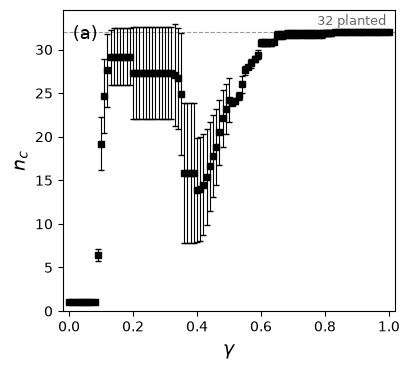

In [3]:
fig = sweep.plot_n_communities()
ax = fig.axes[0]
ax.axhline(N_BLOCKS, color="0.6", lw=0.8, ls="--", zorder=0)
ax.annotate(f"{N_BLOCKS} planted", (1.0, N_BLOCKS), xytext=(-2, 3),
            textcoords="offset points", ha="right", va="bottom",
            color="0.4", fontsize=9)
fig.savefig("nc_vs_gamma_sbm.png", dpi=200)

## 4. Communities and null weight side by side

The red lines mark the two resolutions where the recovered structure changes
character; `n_c` and `b_p` turn at the same places.

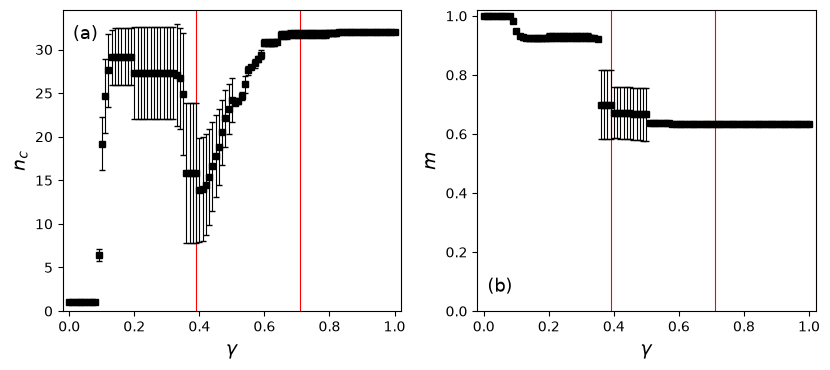

In [4]:
fig = sweep.plot_n_communities_mod_regularizer()
for ax in fig.axes:
  ax.axvline(0.39, color="red", lw=0.8, zorder=0)
  ax.axvline(0.71, color="red", lw=0.8, zorder=0)
fig.savefig("nc_bp_vs_gamma_sbm.png", dpi=200)